<a href="https://colab.research.google.com/github/VK-learner/Netflix-Data-Analysis/blob/main/notebooks/movie%20data%20analysis%20netflix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Netflix, founded on August 29, 1997,
in Scotts Valley, California, by Reed
Hastings and Marc Randolph, began
as a DVD-by-mail service. Hastings, a
computer scientist and
mathematician, co-founded the
company after being inspired by a
hefty late fee from a traditional video
rental store. Randolph, a marketing
executive, played a pivotal role in
shaping Netflix's early user interface
and branding.

In 2007, Netflix introduced streaming services,
allowing subscribers to watch movies and TV
shows instantly online. This strategic shift
capitalized on the growing internet bandwidth
and changing consumer preferences, propelling
Netflix into a leading global streaming platform.
By 2010, the company began its international
expansion, starting with Canada, and by 2016, it
was available in over 190 countries.

As of 2024, Netflix reported a revenue of
nearly $10 billion in the third quarter, with
profits reaching $2.4 billion.
The platform boasts over 283 million paid
memberships across more than 190
countries, offering a vast library of TV
series, films, and games in various genres
and languages.

Overall, Netflix's evolution from a DVD
rental service to a global streaming giant
underscores its adaptability and innovative
approach in the entertainment industry.

![Netflix Logo](https://github.com/VK-learner/Netflix-Data-Analysis/blob/main/images/netflix.png?raw=1)

Netflix is known for its work in data science, Al, and ML, particularly for building strong
recommendation models and algorithms that understand customer behavior and patterns.
Suppose you are working in a data-driven job role, and you have a dataset of more than
9,000 movies. You need to solve the following questions to help the company make
informed business decisions accordingly.

1) What is the most frequent genre of movies released on Netflix?
2) What genres has highest votes?
3) What movie got the highest popularity? what's its genre?
4) What movie got the lowest popularity? what's its genre?
5) Which year has the most filmmed movies?

In [13]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/Colab Notebooks/Netflix-Data-Analysis')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# Loading dataset with lineterminator to fix Buffer overflow error
df = pd.read_csv('data/mymoviedb.csv', lineterminator='\n')
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [16]:
# Viewing dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


In [17]:
# Exploring Genre column
df['Genre'].head()

,Genre
0,"Action, Adventure, Science Fiction"
1,"Crime, Mystery, Thriller"
2,Thriller
3,"Animation, Comedy, Family, Fantasy"
4,"Action, Adventure, Thriller, War"


In [18]:
# Check for duplicated rows
df.duplicated().sum()

np.int64(0)

In [19]:
# Summary statistics
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


In [20]:
# Cast Release_Date to datetime and extract year
df['Release_Date'] = pd.to_datetime(df['Release_Date'])
print(df['Release_Date'].dtypes)

df['Release_Date'] = df['Release_Date'].dt.year
df['Release_Date'].dtypes

datetime64[ns]


dtype('int32')

In [21]:
# Drop unnecessary columns
cols = ['Overview', 'Original_Language', 'Poster_Url']
df.drop(cols, axis=1, inplace=True)
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='object')

In [22]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


In [23]:
# Function to categorize a column based on quartiles
def catigorize_col(df, col, labels):
    """
    Categorizes a column based on its quartiles.

    Args:
        df  : DataFrame being processed
        col : Column name to categorize (str)
        labels : List of labels from min to max

    Returns:
        df with the categorized column
    """
    edges = [
        df[col].describe()['min'],
        df[col].describe()['25%'],
        df[col].describe()['50%'],
        df[col].describe()['75%'],
        df[col].describe()['max']
    ]
    df[col] = pd.cut(df[col], edges, labels=labels, duplicates='drop')
    return df

# Define labels
labels = ['not_popular', 'below_avg', 'average', 'popular']

# Categorize Vote_Average
catigorize_col(df, 'Vote_Average', labels)

# Confirm changes
df['Vote_Average'].unique()

['popular', 'below_avg', 'average', 'not_popular', NaN]
Categories (4, object): ['not_popular' < 'below_avg' < 'average' < 'popular']

In [24]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


In [25]:
# Value counts of Vote_Average
df['Vote_Average'].value_counts()

,count
Vote_Average,
not_popular,2467
popular,2450
average,2412
below_avg,2398


In [26]:
# Drop NaN rows created by pd.cut
df.dropna(inplace=True)

# Confirm no nulls
df.isna().sum()

,0
Release_Date,0
Title,0
Popularity,0
Vote_Count,0
Vote_Average,0
Genre,0


In [27]:
# Split genres into lists
df['Genre'] = df['Genre'].str.split(', ')

# Explode so each row has one genre
df = df.explode('Genre').reset_index(drop=True)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


In [28]:
# Cast Genre to category type
df['Genre'] = df['Genre'].astype('category')
df['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25552 entries, 0 to 25551
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25552 non-null  int32   
 1   Title         25552 non-null  object  
 2   Popularity    25552 non-null  float64 
 3   Vote_Count    25552 non-null  int64   
 4   Vote_Average  25552 non-null  category
 5   Genre         25552 non-null  category
dtypes: category(2), float64(1), int32(1), int64(1), object(1)
memory usage: 749.6+ KB


In [30]:
df.nunique()

,0
Release_Date,100
Title,9415
Popularity,8088
Vote_Count,3265
Vote_Average,4
Genre,19


In [31]:
# Set seaborn style
sns.set_style('whitegrid')

In [32]:
# Q1: What is the most frequent genre?
df['Genre'].describe()

,Genre
count,25552
unique,19
top,Drama
freq,3715


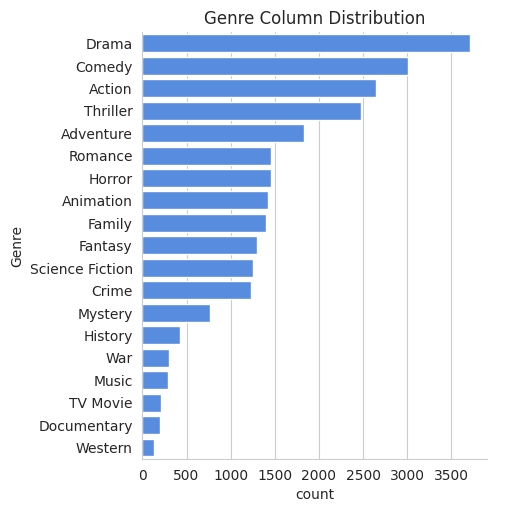

In [33]:
sns.catplot(y='Genre', data=df, kind='count',
            order=df['Genre'].value_counts().index,
            color='#4287f5')
plt.title('Genre Column Distribution')
plt.show()

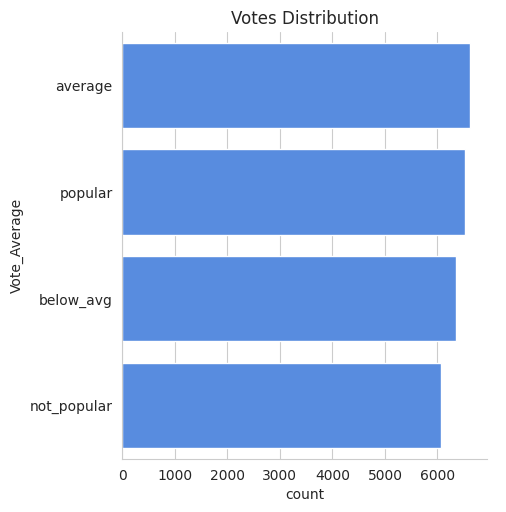

In [34]:
# Q2: Which genres have the highest votes?
sns.catplot(y='Vote_Average', data=df, kind='count',
            order=df['Vote_Average'].value_counts().index,
            color='#4287f5')
plt.title('Votes Distribution')
plt.show()

In [35]:
# Q3: Which movie has the highest popularity?
df[df['Popularity'] == df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction


In [36]:
# Q4: Which movie has the lowest popularity?
df[df['Popularity'] == df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25546,2021,The United States vs. Billie Holiday,13.354,152,average,Music
25547,2021,The United States vs. Billie Holiday,13.354,152,average,Drama
25548,2021,The United States vs. Billie Holiday,13.354,152,average,History
25549,1984,Threads,13.354,186,popular,War
25550,1984,Threads,13.354,186,popular,Drama
25551,1984,Threads,13.354,186,popular,Science Fiction


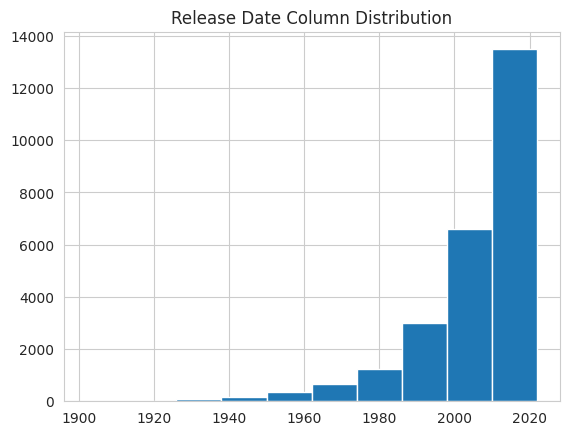

In [37]:
# Q5: Which year had the most filmed movies?
df['Release_Date'].hist()
plt.title('Release Date Column Distribution')
plt.show()

## Conclusions

**Q1: Most frequent genre?**
Drama is the most frequent genre, appearing more than 14% of the time across 19 genres.

**Q2: Genre with highest votes?**
Drama dominates with 18.5% of popular-voted movies out of 25.5% total popular entries.

**Q3: Highest popularity movie?**
Spider-Man: No Way Home (2021) — Genres: Action, Adventure, Science Fiction.

**Q4: Lowest popularity movie?**
The United States vs. Billie Holiday (2021) — Genres: Music, Drama, History.

**Q5: Year with most filmed movies?**
Year 2020 had the highest number of movies in the dataset.

In [53]:
!git add README.md
!git commit -m "Update README with full documentation"
!git push origin main

[main 7a857f7] Update README with full documentation
 1 file changed, 109 insertions(+), 36 deletions(-)
 rewrite README.md (99%)
Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 1.60 KiB | 327.00 KiB/s, done.
Total 3 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/VK-learner/Netflix-Data-Analysis.git
   25bdf9b..7a857f7  main -> main


In [54]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/movie data analysis netflix.ipynb

no changes added to commit (use "git add" and/or "git commit -a")
